# Redes en TensorFlow (Keras)

- Keras es una API para realizar *deep learning* disponible mediante distintos "backends".
- Uno de estos *backends* para Keras es implementado por TensorFlow. TensorFlow normalmente se utiliza para procesar datos eficientemente.
- La documentación de la API se encuentra aquí: https://keras.io/api/models/

## TensorFlow Dataset

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.3JODBV_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.3JODBV_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.
Labels del dataset:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


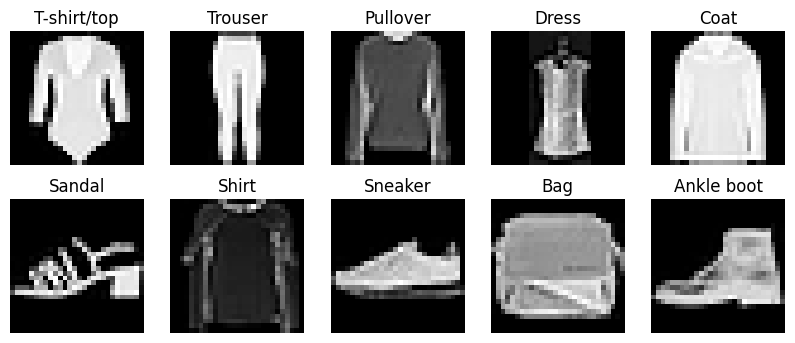

In [ ]:
# Importamos dataset Fashion de MNIST
# https://www.tensorflow.org/datasets/overview

# Quiero conocer información del dataset, así que es importante
# traer su metadata con parámetro with_info=True
(ds_train, ds_test), ds_info = tfds.load(
    "fashion_mnist",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

# Reviso los labels
class_names = ds_info.features["label"].names
print("Labels del dataset:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")


# Obtengo un ejemplo por clase con un diccionario
ejemplos = {}
num_classes = len(class_names)

for image, label in ds_train:
    label = int(label.numpy())
    if label not in ejemplos:
        ejemplos[label] = image.numpy()
    if len(ejemplos) == num_classes:
        break

# Y los imprimo con su label correspondiente
plt.figure(figsize=(10, 4))
for label, image in ejemplos.items():
    plt.subplot(2, 5, label + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.show()

In [ ]:
# Tamaño de cada split
print(len(ds_train), len(ds_test))

# Dimensiones de cada dato
print(ds_train.element_spec)

60000 10000
(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))


In [ ]:
# En este momento mis datos son de tipo TensorSpec,
# por lo que deseo convertirlos a Numpy para poder trabajarlos
# como de costrumbre

# Conversión de Train
X_train, y_train = [], []

for image, label in tfds.as_numpy(ds_train):
    X_train.append(image)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

In [ ]:
# Conversión de Test

X_test, y_test = [], []

for image, label in tfds.as_numpy(ds_test):
    X_test.append(image)
    y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 28, 28, 1) (60000,)
(10000, 28, 28, 1) (10000,)


In [ ]:
# Voy a divir mi split de entrenamiento en train/val
# 55.000 elementos para train, 5.000 para val.
# Además, voy a normalizar las intensidades de los datos
# de entrenamiento de [0, 255] a [0, 1]

X_train, X_val = X_train[5000:] / 255, X_train[:5000] / 255
y_train, y_val = y_train[5000:], y_train[:5000]

print(X_train.shape, X_val.shape)

(55000, 28, 28, 1) (5000, 28, 28, 1)


## Construir el modelo

- Para esto, se utiliza la Sequential API, es decir, cada capa que se agrega al modelo va después de la otra.
- La primera capa se considera como las entradas de la red. A menudo se utiliza la capa "InputLayer".
  
  - En este caso, como estamos utilizando una imagen, debemos convertirla a un vector de características, por lo que se utiliza la capa aplanadora que lleva la matriz 28x28 a un vector de 784.

- Luego, añadimos las capas densas o "Dense". Estas conectan todas las entradas a cada unidad oculta de la capa.

- La capa de salida no se debe especificar, pero sí notamos que la activación es SoftMax y termina con cierta cantidad de específica neuronas.

- Las activaciones se encuentran en https://keras.io/api/layers/activations/.

In [ ]:
def build_model(n_classes):
    model = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[28, 28]),     # Capa de entrada Flatten
        keras.layers.Dense(20, activation="relu"),      # Hidden 1
        keras.layers.Dense(20, activation="relu"),      # Hidden 2
        keras.layers.Dense(n_classes, activation="softmax")    # Capa de salida para clasificación
    ])
    return model

# Importante para no duplicar modelos en cada ejecución
backend.clear_session()

model = build_model(len(class_names))

# Resumen visual con número de parámetros del modelo
model.summary()

# Capa oculta 1
h1 = model.layers[1]
weights, biases = h1.get_weights()

print(weights.shape, biases.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        15,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,330 (63.79 KB)

 Trainable params: 16,330 (63.79 KB)

 Non-trainable params: 0 (0.00 B)

(784, 20) (20,)


## Compilar el modelo

- Necesario para especificar la función de pérdida y el optimizador.

Se pueden ver en https://keras.io/losses, https://keras.io/optimizers y https://keras.io/metrics.


In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",   # Función de pérdida
    optimizer="sgd",                          # Optimizador
    metrics=["accuracy"]                      # Listado de métricas a evaluar durante el entrenamiento
)

In [ ]:
# Entrenamiento
trained_model = model.fit(
    X_train, y_train,                     # Datos y etiquetas de entrenamiento
    batch_size = 50,                      # Hiperparámetro 1
    epochs=30,                            # Hiperparámetro 2
    validation_data=(X_val, y_val),   # Aquí se entregan los splits de validación
)

# El método fit tiene un parámetro validation_split que nos pudo haber ahorrado
# la división manual de los splits de entrenamiento y validación

Epoch 1/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5021 - loss: 1.4592 - val_accuracy: 0.7726 - val_loss: 0.6613
Epoch 2/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7817 - loss: 0.6358 - val_accuracy: 0.8132 - val_loss: 0.5526
Epoch 3/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8088 - loss: 0.5468 - val_accuracy: 0.8258 - val_loss: 0.5052
Epoch 4/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8194 - loss: 0.5105 - val_accuracy: 0.8300 - val_loss: 0.4929
Epoch 5/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8279 - loss: 0.4932 - val_accuracy: 0.8338 - val_loss: 0.4803
Epoch 6/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8357 - loss: 0.4684 - val_accuracy: 0.8444 - val_loss: 0.4613
Epoch 7/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8392 - loss: 0.4572 - val_accuracy: 0.8440 - val_loss: 0.4472
Epoch 8/30
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8420 - loss: 0.4465 - 

## Métricas y visualizaciones

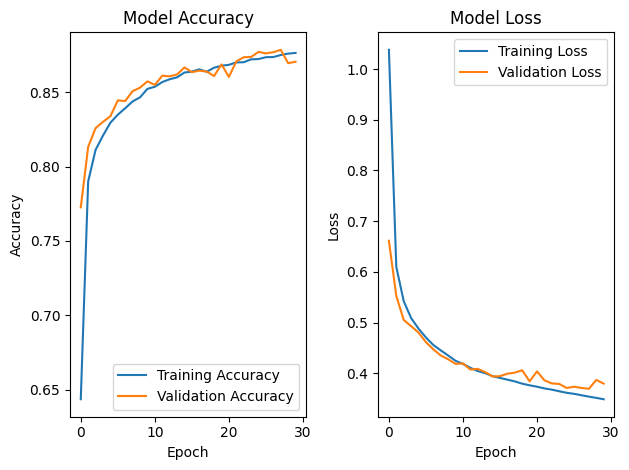

In [ ]:
plt.subplot(1, 2, 1)
plt.plot(trained_model.history['accuracy'], label='Training Accuracy')
plt.plot(trained_model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trained_model.history['loss'], label='Training Loss')
plt.plot(trained_model.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Vamos a hacer una pseudo-prueba, entregándole una porción
# del conjunto de prueba al modelo entrenado (10 elementos).

X_semitest = X_test[:10] / 255.
y_pred = model.predict(X_semitest)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


[4 4 9 7 5 1 0 5 7 4]
[4 4 9 9 5 1 0 5 7 4]
['Coat' 'Coat' 'Ankle boot' 'Ankle boot' 'Sandal' 'Trouser' 'T-shirt/top'
 'Sandal' 'Sneaker' 'Coat']


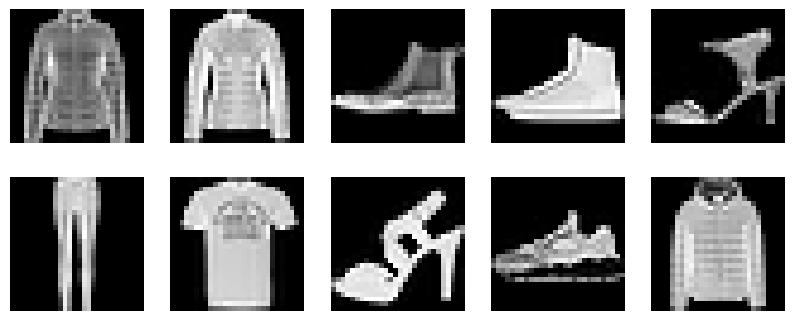

In [ ]:
predicted_classes = y_pred.argmax(axis=1)
print(y_test[:10])          # Clases correctas
print(predicted_classes)    # Predicciones

print(np.array(class_names)[predicted_classes])

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_semitest[i].squeeze(), cmap="gray")
    plt.axis("off")

# Utilizar Pytorch y CUDA

In [ ]:
import torch

# En Google Colab se suele usar el kernel T4 con GPU
if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
else:
    raise Exception("No GPU")

1
Tesla T4


La multiplicación de matrices/tensores también puede realizarse con torch.mm o torch.matmul.

**Importante**: el operador "*" realiza multiplicación posición a posición, diferente de usar "@" o la función matmul.

Documentación de referencia: https://docs.pytorch.org/docs/2.9/generated/torch.matmul.html

In [ ]:
# Atención al device donde se almacena cada tensor, ambos en GPU

identity = torch.eye(3, device="cuda:0") # matriz identidad 3 x 3
m = torch.tensor([[1., 2., 3.], [4., 5., 6,]], device="cuda:0") # 2 x 3

# print(m * identity) Error de dimensiones
print(m @ identity)

tensor([[1., 2., 3.],
        [4., 5., 6.]], device='cuda:0')


In [ ]:
# No se pueden operar con tensores que son almacenados en dispositivos diferentes
new_id = torch.eye(3)   # En CPU
print(new_id.device, identity.device)
new_id * identity

cpu cuda:0


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
# Se pueden cambiar los dispositivos de almacenamiento

# a CPU
identity = identity.cpu()
new_id * identity

# a CUDA
identity = identity.to("cuda:0")
new_id = new_id.to("cuda:0")
print(identity.device, new_id.device)
new_id * identity

cuda:0 cuda:0


tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], device='cuda:0')

# Redes en PyTorch

- A diferencia de Keras, las redes del estilo PyTorch se suelen implementar mediante clases (no en estricto rigor, pero es la buena práctica y forma canónica de diseñar redes debido al paradigma OOP al que se suscribe PyTorch).

Pequeña guía tutorial de referencia: https://docs.pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html

In [ ]:
# Definimos la clase MLP, que será una subclase del módulo torch.nn.Module
class MLP(torch.nn.Module):

    # Define arquitectura de la red. Es la misma que en Keras
    def __init__(self, n_classes): # Se pueden entregar las neuronas por capa como parámetro
        super(MLP, self).__init__()

        self.flatten = torch.nn.Flatten()
        self.fc1 = torch.nn.Linear(28 * 28, 20, bias = True)
        self.fc2 = torch.nn.Linear(20, 20, bias = True)
        self.fc3 = torch.nn.Linear(20, n_classes, bias = True)
1
    # Define el paso de parámetros de capa a capa (cómo interactúan)
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        logits = self.fc3(x)

        return logits

Como PyTorch maneja su propio formato de tensores distinto a Numpy Arrays, tenemos dos opciones: 1) convertir nuestros datos al tipo de dato PyTorch Tensor (No recomendado). 2) Utilizar un DataLoader

## Datasets y DataLoader

La definición de Datasets de PyTorch nos permite definir la forma en la que cargamos los datos en forma completamente personalizada.

Por ejemplo, si tenemos un dataset de gran tamaño, de alrededor de 10GB, todo este conjunto no es posible cargar en una sola pasada en la RAM.

Sin embargo, mediante un Dataset y Dataloader, los datos se pueden cargar en batches según se necesiten.

In [ ]:
from torch.utils.data import Dataset, DataLoader

# Definición de un Dataset personalizado que convierte de Numpy
# a Tensor
class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32) / 255
        self.y = torch.tensor(y, dtype=torch.long)
https://playground.tensorflow.org/
    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [ ]:
train_dataset = NumpyDataset(X_train, y_train)
val_dataset   = NumpyDataset(X_val, y_val)
test_dataset  = NumpyDataset(X_test, y_test)

X, y = train_dataset[0]
print(X.shape, y)

torch.Size([28, 28, 1]) tensor(4)


In [ ]:
# DataLoader de PyTorch con el nuevo Dataset

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)